In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
from dataclasses import dataclass
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
import torch.nn.functional as F
from matplotlib.patches import Patch

sys.path.append('../') 
try:
    from NeuroHDC.FHRR import *
    from NeuroHDC.fn import *
    from conformalHDC.models import *
    from conformalHDC.methods import *
    from conformalHDC.utils import *
except ImportError:
    print("Warning: NeuroHDC or conformalHDC modules not found. Ensure '../' is in path.")

## Full plot

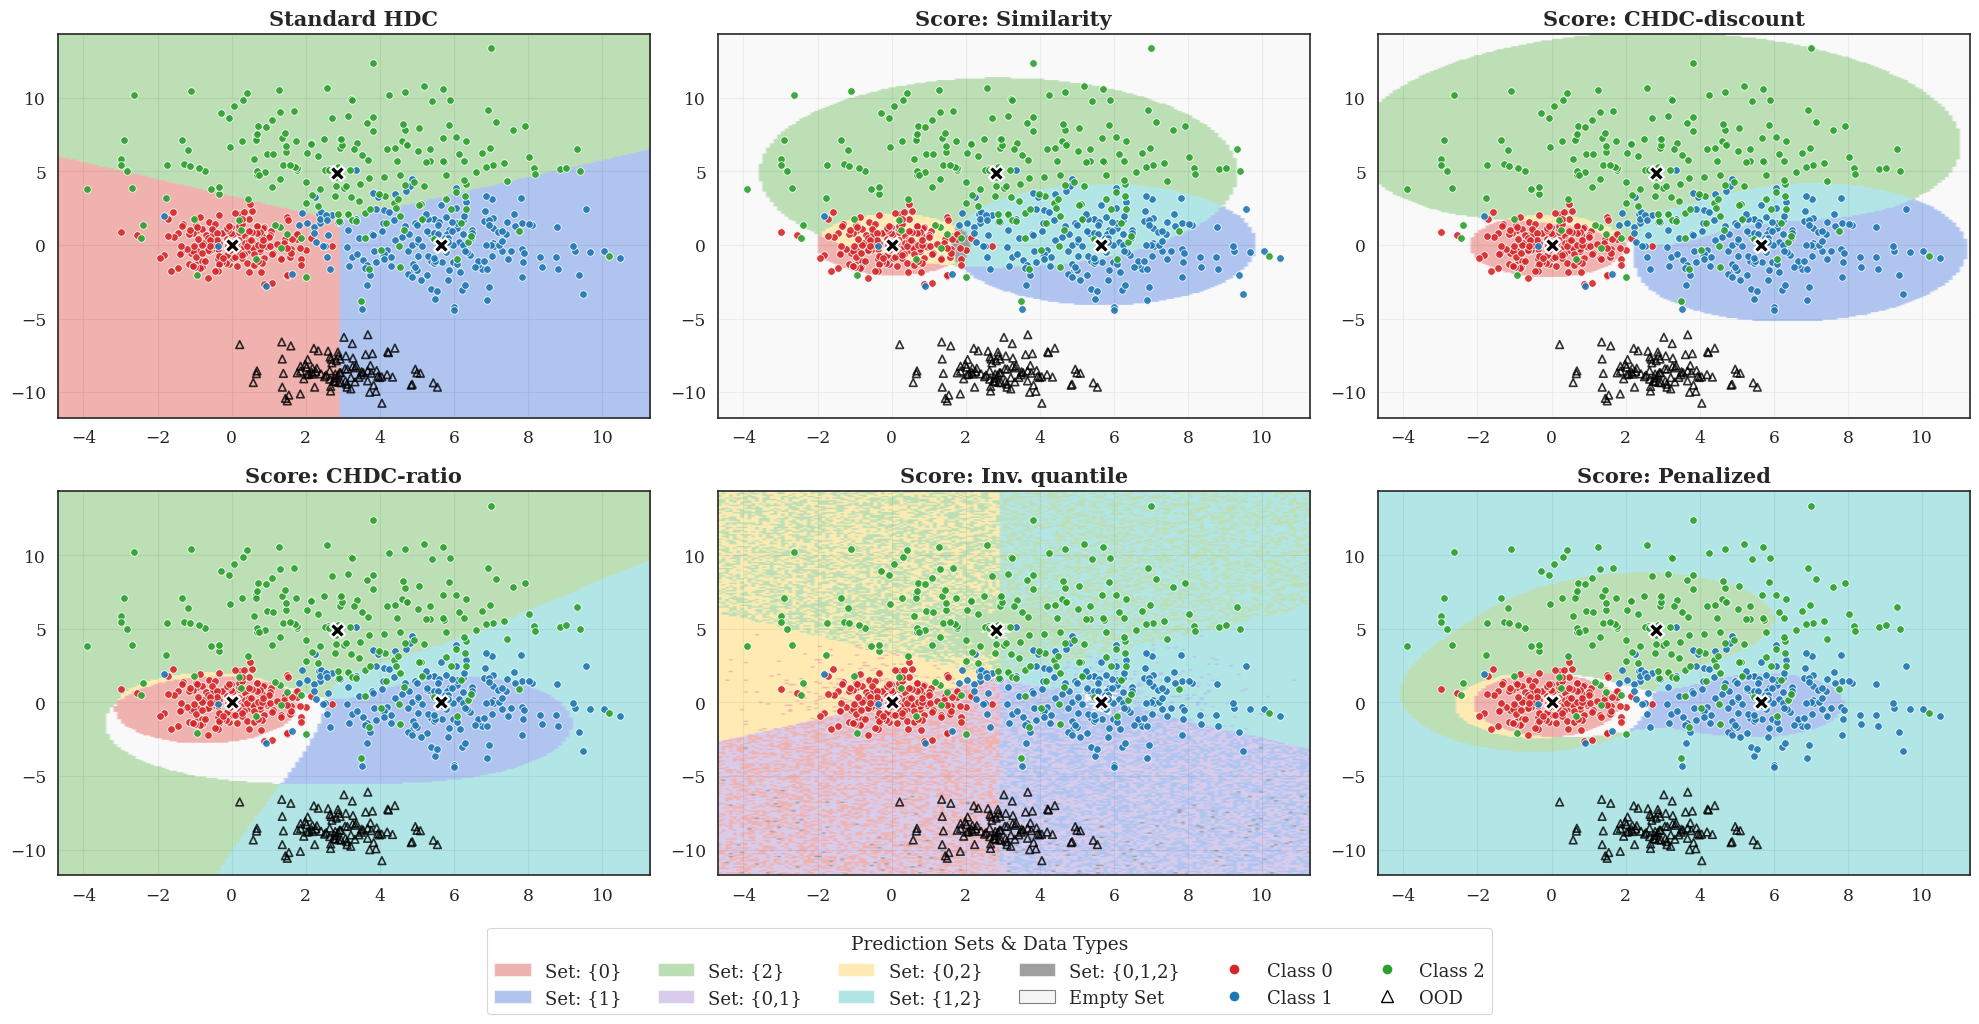

In [75]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import seaborn as sns

# ==========================================
# 1. SETUP & CONSTANTS
# ==========================================
sns.set_context("paper", font_scale=1.4)
sns.set_style("white")
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.linewidth'] = 1.2

# --- Color Definitions ---
# 1. Background Regions (V2 Pastel Scheme)
REGION_COLORS = {
    frozenset():            (0.96, 0.96, 0.96), # Empty: Near White
    frozenset([0]):         (0.89, 0.40, 0.38), # Soft Red
    frozenset([1]):         (0.38, 0.55, 0.89), # Soft Blue
    frozenset([2]):         (0.48, 0.75, 0.42), # Soft Green
    frozenset([0, 1]):      (0.70, 0.60, 0.85), # Purple (Overlap 0+1)
    frozenset([0, 2]):      (1.0, 0.85, 0.40), # Orange/Tan (Overlap 0+2)
    frozenset([1, 2]):      (0.40, 0.80, 0.80), # Teal (Overlap 1+2)
    frozenset([0, 1, 2]):   (0.25, 0.25, 0.25)  # Dark Charcoal
}

# 2. Data Points (Saturated/Strong colors to "Pop")
# Using Matplotlib 'tab' colors for strong contrast
DATA_COLORS = {
    0: '#d62728',  # Strong Red
    1: '#1f77b4',  # Strong Blue
    2: '#2ca02c'   # Strong Green
}

def get_region_color(pset):
    key = frozenset(pset)
    return REGION_COLORS.get(key, (0.9, 0.9, 0.9))

# ==========================================
# 2. DATA GENERATION
# ==========================================
def setup_triangle_geometry(separation_factor, rng):
    dim = 2
    ref_sigma = 1.0
    r_ref = ref_sigma * np.sqrt(dim)
    dist = separation_factor * (r_ref + r_ref)

    mu0 = np.array([0.0, 0.0])
    mu1 = np.array([dist, 0.0])
    mu2 = np.array([dist / 2, (np.sqrt(3) / 2) * dist])
    
    return np.stack([mu0, mu1, mu2]).astype(np.float32)

def generate_samples_3class(n_samples, prototypes, sigmas, rng):
    X_list = []
    y_list = []
    dim = prototypes.shape[1]
    
    for label, (mu, sigma) in enumerate(zip(prototypes, sigmas)):
        X_c = rng.randn(n_samples, dim) * sigma + mu
        X_list.append(X_c)
        y_list.append(np.full(n_samples, label))
        
    X = np.concatenate(X_list).astype(np.float32)
    y = np.concatenate(y_list).astype(int)
    return X, y

def generate_ood_blob(n_samples, prototypes, rng):
    center = np.mean(prototypes, axis=0)
    direction = np.array([0.0, -1.0]) 
    dist = np.linalg.norm(prototypes[2] - prototypes[0]) * 1.8
    mu_ood = center + direction * dist
    X_ood = rng.randn(n_samples, 2) * 1.0 + mu_ood 
    return X_ood.astype(np.float32)

# ==========================================
# 3. EXPERIMENT CONFIG
# ==========================================
SEED = 0
rng = np.random.RandomState(SEED)
SCORE_TYPES = ["sim", "discount", "ratio", "inverse_quantile", "penalized"]
SCORE_NAMES = ['Similarity', "CHDC-discount", "CHDC-ratio", "Inv. quantile", "Penalized"]
if len(SCORE_TYPES) > 5: SCORE_TYPES = SCORE_TYPES[:5]

SAMPLES_PER_CLASS = 1000
SEPARATION_CONST = 2.0 
SIGMAS = [1.0, 2, 3] 
ALPHA = 0.1
MARGINAL = False 

prototypes = setup_triangle_geometry(SEPARATION_CONST, rng)
X_full, y_full = generate_samples_3class(SAMPLES_PER_CLASS, prototypes, SIGMAS, rng)
X_ood = generate_ood_blob(100, prototypes, rng)

indices = np.arange(len(X_full))
rng.shuffle(indices)
n_total = len(X_full)
n_cal   = int(0.8 * n_total)
n_test  = int(0.2 * n_total)
idx_cal   = indices[: n_cal]
idx_test  = indices[n_cal :]
X_cal,   y_cal   = X_full[idx_cal],   y_full[idx_cal]
X_test,  y_test  = X_full[idx_test],  y_full[idx_test]

# Grid Setup
x_min, x_max = np.min([X_test[:,0].min(), X_ood[:,0].min()]) - 0.8, np.max([X_test[:,0].max(), X_ood[:,0].max()]) + 0.8
y_min, y_max = np.min([X_test[:,1].min(), X_ood[:,1].min()]) - 1, np.max([X_test[:,1].max(), X_ood[:,1].max()]) + 1
resolution = 0.1

xx, yy = np.meshgrid(np.arange(x_min, x_max, resolution),
                     np.arange(y_min, y_max, resolution))
grid_points = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)

# ==========================================
# 4. PLOTTING
# ==========================================

# Helper: Plot Data with High Contrast ("Pop")
def plot_data_contrast(ax):
    # Plot Class 0
    ax.scatter(X_test[y_test==0, 0], X_test[y_test==0, 1], 
               color=DATA_COLORS[0], s=30, alpha=0.9, 
               edgecolors='white', linewidth=0.6, zorder=3)
    # Plot Class 1
    ax.scatter(X_test[y_test==1, 0], X_test[y_test==1, 1], 
               color=DATA_COLORS[1], s=30, alpha=0.9, 
               edgecolors='white', linewidth=0.6, zorder=3)
    # Plot Class 2
    ax.scatter(X_test[y_test==2, 0], X_test[y_test==2, 1], 
               color=DATA_COLORS[2], s=30, alpha=0.9, 
               edgecolors='white', linewidth=0.6, zorder=3)
    
    # Plot OOD
    ax.scatter(X_ood[:, 0], X_ood[:, 1], 
               facecolors='none', edgecolors='black', 
               marker='^', s=30, linewidth=1.2, alpha=0.8, zorder=3)
    
    # Plot Prototypes
    ax.scatter(prototypes[:, 0], prototypes[:, 1], c='black', 
               marker='X', s=120, edgecolor='white', linewidth=1.5, zorder=5)
    
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.grid(True, linestyle='-', alpha=0.5, zorder=0)

# Wide figure size to get the "flatter" look
fig, axes = plt.subplots(2, 3, figsize=(20, 11)) 
axes = axes.flatten()
filling_alpha=0.5

# Note: Ensure ConformalHDC is imported/defined before running
chdc = ConformalHDC(class_HVs=prototypes, class_labels=[0, 1, 2],
                    sim_measure="euclidean", random_state=SEED)

# --- A. Plot 5 Conformal Variants ---
for idx, stype in enumerate(SCORE_TYPES):
    ax = axes[idx+1]
    
    chdc.compute_calib_scores(X_cal, y_cal, score_type=stype)
    psets = chdc.set_valued_CP(grid_points, ALPHA, marginal=MARGINAL)
    
    region_img = np.zeros((xx.shape[0], xx.shape[1], 3))
    for i, pset in enumerate(psets):
        r, c = divmod(i, xx.shape[1])
        region_img[r, c] = get_region_color(pset)
    
    # Low Alpha for background to make data pop
    ax.imshow(region_img, extent=(x_min, x_max, y_min, y_max), 
              origin='lower', alpha=filling_alpha, aspect='auto', zorder=1)
    
    plot_data_contrast(ax)
    ax.set_title(f"Score: {SCORE_NAMES[idx]}", fontsize=15, fontweight='bold')

# --- B. Plot Vanilla HDC ---
ax_vanilla = axes[0]

dists = []
for p in prototypes:
    d = np.linalg.norm(grid_points - p, axis=1)
    dists.append(d)
dists = np.stack(dists, axis=1)
preds_vanilla = np.argmin(dists, axis=1)

region_img_v = np.zeros((xx.shape[0], xx.shape[1], 3))
for i, pred in enumerate(preds_vanilla):
    r, c = divmod(i, xx.shape[1])
    region_img_v[r, c] = get_region_color({pred})

ax_vanilla.imshow(region_img_v, extent=(x_min, x_max, y_min, y_max), 
                  origin='lower', alpha=filling_alpha, aspect='auto', zorder=1)
plot_data_contrast(ax_vanilla)
ax_vanilla.set_title("Standard HDC", fontsize=15, fontweight='bold')

# ==========================================
# 5. LEGEND (V1 Style + V2 Colors)
# ==========================================
legend_patches = [
    # Singletons
    Patch(facecolor=REGION_COLORS[frozenset([0])], alpha=filling_alpha, label='Set: {0}'),
    Patch(facecolor=REGION_COLORS[frozenset([1])], alpha=filling_alpha, label='Set: {1}'),
    Patch(facecolor=REGION_COLORS[frozenset([2])], alpha=filling_alpha, label='Set: {2}'),
    # Uncertainty
    Patch(facecolor=REGION_COLORS[frozenset([0,1])], alpha=filling_alpha, label='Set: {0,1}'),
    Patch(facecolor=REGION_COLORS[frozenset([0,2])], alpha=filling_alpha, label='Set: {0,2}'),
    Patch(facecolor=REGION_COLORS[frozenset([1,2])], alpha=filling_alpha, label='Set: {1,2}'),
    Patch(facecolor=REGION_COLORS[frozenset([0,1,2])], alpha=filling_alpha, label='Set: {0,1,2}'),
    # Empty
    Patch(facecolor=REGION_COLORS[frozenset([])], edgecolor='gray', label='Empty Set'),
    # Points (Using the high contrast data colors)
    Line2D([0], [0], marker='o', color='w', markerfacecolor=DATA_COLORS[0], markersize=8, label='Class 0'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=DATA_COLORS[1], markersize=8, label='Class 1'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=DATA_COLORS[2], markersize=8, label='Class 2'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='none', markeredgecolor='black', markersize=8, label='OOD')
]

plt.tight_layout(rect=[0, 0.10, 1, 0.95]) # Reserve bottom for legend

fig.legend(handles=legend_patches, loc='lower center', bbox_to_anchor=(0.5, 0.01),
           ncol=6, fontsize=13, frameon=True, title="Prediction Sets & Data Types")

plt.savefig("../results/plots/decision_boundary_comparison.pdf", bbox_inches='tight')
plt.show()

## Two sub plots

In [71]:
# ==========================================
# PLOTTING HELPERS
# ==========================================
def plot_data_contrast(ax, dot_size=38, center_size=160):
    # Plot Class 0
    ax.scatter(X_test[y_test==0, 0], X_test[y_test==0, 1], 
               color=DATA_COLORS[0], s=dot_size, alpha=0.9, 
               edgecolors='white', linewidth=0.6, zorder=3)
    # Plot Class 1
    ax.scatter(X_test[y_test==1, 0], X_test[y_test==1, 1], 
               color=DATA_COLORS[1], s=dot_size, alpha=0.9, 
               edgecolors='white', linewidth=0.6, zorder=3)
    # Plot Class 2
    ax.scatter(X_test[y_test==2, 0], X_test[y_test==2, 1], 
               color=DATA_COLORS[2], s=dot_size, alpha=0.9, 
               edgecolors='white', linewidth=0.6, zorder=3)
    # Plot OOD
    ax.scatter(X_ood[:, 0], X_ood[:, 1], 
               facecolors='none', edgecolors='black', 
               marker='^', s=dot_size, linewidth=1.2, alpha=0.8, zorder=3)
    # Plot Prototypes
    ax.scatter(prototypes[:, 0], prototypes[:, 1], c='black', 
               marker='X', s=center_size, edgecolor='white', linewidth=1.5, zorder=5)
    
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    plt.rcParams['xtick.labelsize'] = 15
    plt.rcParams['ytick.labelsize'] = 15

    ax.grid(True, linestyle='-', alpha=0.5, zorder=0)

def add_common_legend(fig):
    legend_patches = [
        # Singletons
        Patch(facecolor=REGION_COLORS[frozenset([0])], alpha=filling_alpha, label='Set: {0}'),
        Patch(facecolor=REGION_COLORS[frozenset([1])], alpha=filling_alpha, label='Set: {1}'),
        Patch(facecolor=REGION_COLORS[frozenset([2])], alpha=filling_alpha, label='Set: {2}'),
        # Uncertainty
        Patch(facecolor=REGION_COLORS[frozenset([0,1])], alpha=filling_alpha, label='Set: {0,1}'),
        Patch(facecolor=REGION_COLORS[frozenset([0,2])], alpha=filling_alpha, label='Set: {0,2}'),
        Patch(facecolor=REGION_COLORS[frozenset([1,2])], alpha=filling_alpha, label='Set: {1,2}'),
        Patch(facecolor=REGION_COLORS[frozenset([0,1,2])], alpha=filling_alpha, label='Set: {0,1,2}'),
        # Empty
        Patch(facecolor=REGION_COLORS[frozenset([])], edgecolor='gray', label='Empty Set'),
        # Points
        Line2D([0], [0], marker='o', color='w', markerfacecolor=DATA_COLORS[0], markersize=10, label='Class 0'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor=DATA_COLORS[1], markersize=10, label='Class 1'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor=DATA_COLORS[2], markersize=10, label='Class 2'),
        Line2D([0], [0], marker='^', color='w', markerfacecolor='none', markeredgecolor='black', markersize=8, label='OOD')
    ]
    fig.legend(handles=legend_patches, loc='lower center', bbox_to_anchor=(0.5, 0.01),
               ncol=6, fontsize=15, frameon=True)

filling_alpha = 0.5

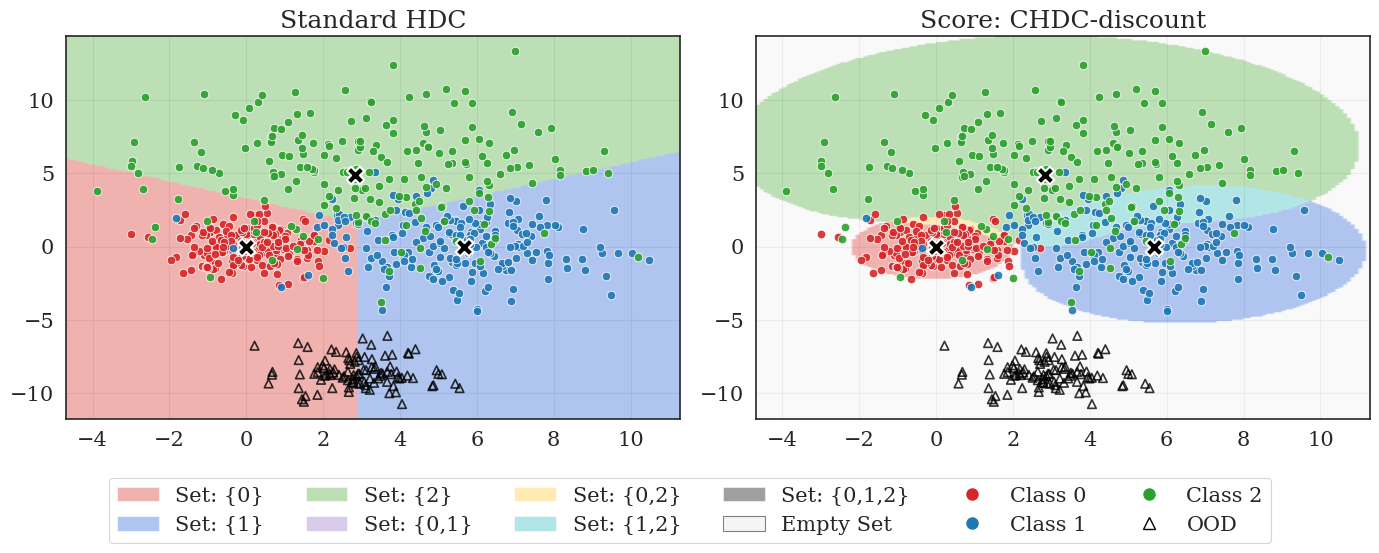

In [72]:
# ==========================================
# FIGURE 1: Standard HDC & CHDC-Discount
# ==========================================
fig1, ax1 = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot 1.1: Standard HDC ---
dists = []
for p in prototypes:
    d = np.linalg.norm(grid_points - p, axis=1)
    dists.append(d)
dists = np.stack(dists, axis=1)
preds_vanilla = np.argmin(dists, axis=1)

region_img_v = np.zeros((xx.shape[0], xx.shape[1], 3))
for i, pred in enumerate(preds_vanilla):
    r, c = divmod(i, xx.shape[1])
    region_img_v[r, c] = get_region_color({pred})

ax1[0].imshow(region_img_v, extent=(x_min, x_max, y_min, y_max), 
               origin='lower', alpha=filling_alpha, aspect='auto', zorder=1)
plot_data_contrast(ax1[0])
ax1[0].set_title("Standard HDC", fontsize=18)

# --- Plot 1.2: CHDC - Discount ---
score_type = "discount"
score_name = "CHDC-discount"

chdc.compute_calib_scores(X_cal, y_cal, score_type=score_type)
psets = chdc.set_valued_CP(grid_points, ALPHA, marginal=MARGINAL)

region_img = np.zeros((xx.shape[0], xx.shape[1], 3))
for i, pset in enumerate(psets):
    r, c = divmod(i, xx.shape[1])
    region_img[r, c] = get_region_color(pset)

ax1[1].imshow(region_img, extent=(x_min, x_max, y_min, y_max), 
              origin='lower', alpha=filling_alpha, aspect='auto', zorder=1)
plot_data_contrast(ax1[1])
ax1[1].set_title(f"Score: {score_name}", fontsize=18)

plt.tight_layout(rect=[0, 0.15, 1, 0.95]) # Reserve bottom for legend
add_common_legend(fig1)
plt.savefig("../results/plots/decision_boundary_part1_standard_discount.pdf", bbox_inches='tight')
plt.show()

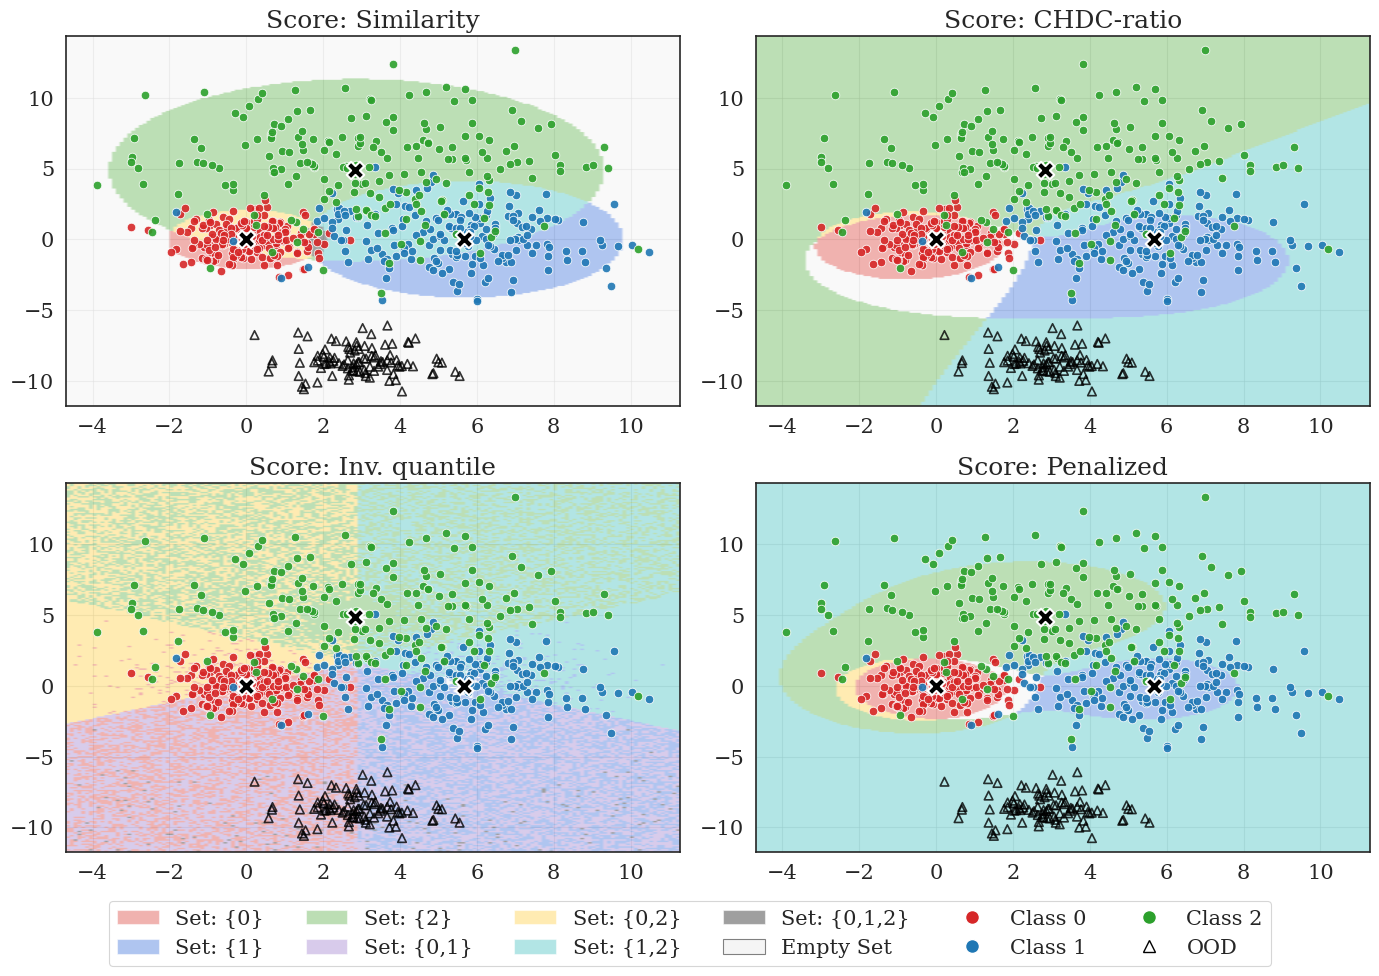

In [74]:
# ==========================================
# FIGURE 2: Sim, Ratio, Inv Quantile, Penalized
# ==========================================
fig2, ax2 = plt.subplots(2, 2, figsize=(14, 10.5))
ax2 = ax2.flatten()

subset_types = ["sim", "ratio", "inverse_quantile", "penalized"]
subset_names = ['Similarity', "CHDC-ratio", "Inv. quantile", "Penalized"]

for idx, stype in enumerate(subset_types):
    curr_ax = ax2[idx]
    
    chdc.compute_calib_scores(X_cal, y_cal, score_type=stype)
    psets = chdc.set_valued_CP(grid_points, ALPHA, marginal=MARGINAL)
    
    region_img = np.zeros((xx.shape[0], xx.shape[1], 3))
    for i, pset in enumerate(psets):
        r, c = divmod(i, xx.shape[1])
        region_img[r, c] = get_region_color(pset)
        
    curr_ax.imshow(region_img, extent=(x_min, x_max, y_min, y_max), 
                  origin='lower', alpha=filling_alpha, aspect='auto', zorder=1)
    
    plot_data_contrast(curr_ax)
    curr_ax.set_title(f"Score: {subset_names[idx]}", fontsize=18)

plt.tight_layout(rect=[0, 0.08, 1, 0.95]) # Reserve bottom for legend
add_common_legend(fig2)
plt.savefig("../results/plots/decision_boundary_part2_variants.pdf", bbox_inches='tight')
plt.show()